# Data Engineering Project Part 2
## Validation, Transformation, and Loading

This notebook documents your team's implementation of Part 2 of the Data Engineering project. You will use this notebook to record your updated code, configurations, evidence of a working pipeline, database queries, and written reflections.

**Instructions:** Work through each section in order. Fill in every cell marked with `[YOUR INPUT HERE]` or `[PASTE HERE]`. Do not delete any section headings or instruction cells.

Submit your completed notebook once you have five successful days of end-to-end pipeline runs recorded in Section 7. (the five days do not need to be consecutive)

---

### Team Information

Fill in the cell below with your team details.

**Team Members** (list each member's name and @pdx.edu email, one per line):

Vinodh Raju - vinodh@pdx.edu

Neha Marlady - nmarlady@pdx.edu

**GCP Project ID:**

cs536-data-engineering

**Vehicle Group Name:**

Shazam

---
## Table of Contents

1. [Review Part 1 and Preview Part 2](#1-review-part-1-and-preview-part-2)
2. [Understanding the BreadCrumb Data](#2-understanding-the-breadcrumb-data)
3. [Handle Out-of-Order Messages](#3-handle-out-of-order-messages)
    - 3.1 [Updated publisher.py](#31-updated-publisherpy)
    - 3.2 [Updated analysis.py (subscriber)](#32-updated-analysispy-subscriber)
    - 3.3 [Updated backup.py (subscriber)](#33-updated-backuppy-subscriber)
4. [Validate the Data](#4-validate-the-data)
    - 4.1 [Assertions](#41-assertions)
    - 4.2 [Implemented Validations](#42-implemented-validations)
5. [Transform the Data](#5-transform-the-data)
6. [Configure the DBMS](#6-configure-the-dbms)
    - 6.1 [Install and Configure PostgreSQL](#61-install-and-configure-postgresql)
    - 6.2 [Connect from Colab](#62-connect-from-colab)
    - 6.3 [Create the BreadCrumb Table](#63-create-the-breadcrumb-table)
7. [Store the BreadCrumb Data](#7-store-the-breadcrumb-data)
8. [Pipeline Run Statistics](#8-pipeline-run-statistics)
9. [Exploratory Data Analysis](#9-exploratory-data-analysis)
    - 9.1 [Sanity-Check Queries](#91-sanity-check-queries)
    - 9.2 [Your Additional Queries](#92-your-additional-queries)
    - 9.3 [Trip Visualization](#93-trip-visualization)
10. [Reflections](#10-reflections)

---
## 1. Review Part 1 and Preview Part 2

### What you built in Part 1

In Part 1 you implemented and automated an initial data pipeline for TriMet BreadCrumb data. Your pipeline runs daily and consists of three programs:

- **publisher.py** -- runs on the Publisher VM (Oregon). Each day it fetches BreadCrumb records from the BusData API for each vehicle in your assigned group and publishes them individually to a GCP Pub/Sub topic (`bc_topic`). After all records are published, it sends a sentinel message to signal that the day's data is complete.
- **analysis.py** -- runs continuously on the Analysis VM (Belgium). It subscribes to `bc_topic` via `analysis_sub`, processes incoming breadcrumbs, and logs daily statistics when the sentinel arrives.
- **backup.py** -- runs continuously on the Backup VM (Taiwan). It subscribes to `bc_topic` via `backup_sub`, writes breadcrumbs to a daily compressed file, and logs statistics when the sentinel arrives.

Your pipeline should already be running every day, gathering, transporting, and backing up data automatically.

### What you will build in Part 2

In Part 2 you will extend the pipeline by updating `analysis.py` to:

1. **Validate** incoming breadcrumb records against a set of defined assertions.
2. **Transform** valid records (create new fields, remove unneeded fields, rename fields).
3. **Load** transformed records into a PostgreSQL database running on your Analysis VM.

You will also use this Colab notebook to connect to that database from the cloud, run exploratory SQL queries, and visualize bus trips on a map.

---
## 2. Understanding the BreadCrumb Data

Before writing validation code, you need to understand what each field in the data means. BreadCrumb records are produced by TriMet's MOBILEreports system (view `veh_cyclic`). Each record represents a single GPS position update for a vehicle, sampled approximately every 5 seconds.

### 2.1 Examine a Sample Record

Use the cell below to fetch a few sample records from the BusData API. Replace `<YOUR_VEHICLE_ID>` with one of the vehicle IDs from your assigned group.

In [ ]:
import requests
import json

vehicle_id = "2903"  # replace with a vehicle ID from your group
url = f"https://busdata.cs.pdx.edu/api/getBreadCrumbs?vehicle_id={vehicle_id}"

response = requests.get(url)
records = response.json()

print(f"Fetched {len(records)} records for vehicle {vehicle_id}")
print()
print("First record:")
print(json.dumps(records[0], indent=2))

Fetched 3197 records for vehicle 2903

First record:
{
  "EVENT_NO_TRIP": 232699261,
  "EVENT_NO_STOP": 232699280,
  "OPD_DATE": "05JAN2023:00:00:00",
  "VEHICLE_ID": 2903,
  "METERS": 61159,
  "ACT_TIME": 52083,
  "GPS_LONGITUDE": -122.779037,
  "GPS_LATITUDE": 45.452312,
  "GPS_SATELLITES": 12.0,
  "GPS_HDOP": 0.7
}


### 2.2 Field Descriptions

The table below lists every field in a BreadCrumb record. The "Improved Description" column is for you to fill in after reviewing [the TriMet documentation](https://drive.google.com/file/d/1XUZudI77WIVWQAP3-EQ62uk88jwYsTlB) and your sample records.

| Field | Type | Basic Description (from TriMet docs) | Improved Description |
|---|---|---|---|
| `EVENT_NO_TRIP` | NUMBER | Trip Index (FK to veh_trip) | [Unique identifier for a bus trip. All breadcrumbs from the same trip share this ID. Used to group GPS readings by journey.] |
| `EVENT_NO_STOP` | NUMBER | Stop or Point Index (FK to veh_stop) | [Identifies the current stop or waypoint in the trip sequence. Links to stop schedule data.] |
| `OPD_DATE` | DATE | Operation day | [The calendar date of the bus service day in format DDMONYYYY:HH:MM:SS. Note: time portion is always midnight (00:00:00).] |
| `VEHICLE_ID` | NUMBER | Vehicle number | [Unique identifier for the physical bus vehicle. Used to track a specific bus across multiple trips and days.] |
| `METERS` | NUMBER | Odometer (cumulative distance traveled from start of trip) | [Cumulative distance in meters traveled from the start of the trip. Resets to 0 at the beginning of each new trip.] |
| `ACT_TIME` | NUMBER | Actual time (seconds elapsed since midnight on OPD_DATE) | [Seconds elapsed since midnight on OPD_DATE. Combined with OPD_DATE gives the exact timestamp of each GPS reading.] |
| `GPS_LONGITUDE` | NUMBER | GPS longitude (WGS 84) | [Geographic longitude coordinate in WGS 84 format. Negative values indicate west of the prime meridian. Portland area is approximately -122.7.] |
| `GPS_LATITUDE` | NUMBER | GPS latitude (WGS 84) | [Geographic latitude coordinate in WGS 84 format. Portland area is approximately 45.5 degrees north.] |
| `GPS_SATELLITES` | NUMBER | Count of GPS satellites used | [Number of satellites used to compute the GPS fix. Higher values indicate more accurate positioning. Typical range is 4–12.] |
| `GPS_HDOP` | NUMBER | Horizontal Dilution of Precision for GPS reading | [Measure of GPS accuracy. Lower values mean better accuracy. Values below 2 are excellent, above 5 indicate poor accuracy.] |


---
## 3. Handle Out-of-Order Messages

### Background

In Part 1 we recommended using a **sentinel message** to signal the end of each day's data. However, GCP Pub/Sub does **not** guarantee message delivery order. As a result, some subscriber processes received the sentinel before all breadcrumb messages had arrived, causing them to stop pulling early and miss up to thousands of records.

### The fix: include a message count in the sentinel

Modify your pipeline as follows:

1. **publisher.py** -- After publishing all breadcrumbs, include the total count of published breadcrumb messages inside the sentinel payload (e.g., as a JSON field named `"total_count"`). Example sentinel payload:
   ```json
   {"sentinel": true, "total_count": 84217}
   ```
2. **analysis.py and backup.py** -- After receiving the sentinel, continue pulling messages from the subscription until the number of breadcrumbs received equals `total_count`. Only then close out the day's processing.

**Note:** This approach does not properly handle duplicate messages, but it is sufficient for our purposes.

If your subscribers already reliably receive all published messages (i.e., you never see missing records), you may skip modifying the sentinel and move on to Section 4. Document your decision below.

**Did you need to modify your pipeline to handle out-of-order messages?**

Yes, We modified the pipeline to handle out-of-order messages using the
total_count sentinel approach.

In publisher.py, we updated the sentinel payload to include the total
number of breadcrumbs published:
{"sentinel": true, "total_count": 736655}

In analysis.py and backup.py, after receiving the sentinel, the subscriber
continues pulling messages until the number of breadcrumbs received equals
total_count. This ensures no messages are missed even if the sentinel
arrives before all breadcrumbs are delivered.

Previously we used a 30-second drain window after receiving the sentinel,
which was unreliable if messages arrived more than 30 seconds late they
would be missed. The total_count approach is more reliable because it
guarantees all messages are received regardless of timing.

### 3.1 Updated `publisher.py`

Paste the complete, final version of `publisher.py` below. If you did not modify it for this section, paste the Part 1 version and note that it was unchanged.

In [ ]:
# publisher.py
# Paste your complete publisher.py code here.
# publisher.py
import requests
import json
import time
from datetime import datetime
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
TOPIC_ID = "bc_topic"

VEHICLE_IDS = [
    2903, 2905, 2907, 2910, 2914, 2915, 2919, 2920, 2921, 2923,
    2924, 2931, 2933, 2939, 3001, 3007, 3010, 3012, 3014, 3018,
    3020, 3027, 3028, 3037, 3042, 3046, 3054, 3055, 3056, 3059,
    3102, 3107, 3108, 3110, 3112, 3113, 3115, 3118, 3121, 3123,
    3125, 3131, 3137, 3138, 3139, 3142, 3144, 3145, 3146, 3158,
    3162, 3166, 3168, 3170, 3204, 3207, 3208, 3209, 3210, 3214,
    3217, 3219, 3223, 3228, 3230, 3231, 3233, 3239, 3240, 3242,
    3246, 3248, 3249, 3250, 3251, 3252, 3260, 3261, 3265, 3267,
    3301, 3304, 3308, 3312, 3315, 3317, 3322, 3326, 3329, 3330,
    3407, 3408, 3412, 3414, 3418, 3505, 3507, 3513, 3518, 3519,
    3521, 3524, 3528, 3529, 3535, 3536, 3545, 3548, 3551, 3552,
    3554, 3561, 3563, 3566, 3568, 3569, 3572, 3576, 3605, 3606,
    3607, 3610, 3611, 3614, 3620, 3621, 3623, 3628, 3631, 3637,
    3647, 3648, 3649, 3702, 3708, 3715, 3716, 3717, 3718, 3719,
    3721, 3724, 3725, 3728, 3730, 3733, 3737, 3739, 3742, 3743,
    3745, 3751, 3755, 3756, 3902, 3909, 3912, 3913, 3915, 3919,
    3925, 3928, 3932, 3935, 3936, 3939, 3940, 3942, 3943, 3950,
    3959, 3962, 3963, 4003, 4006, 4009, 4010, 4021, 4023, 4025,
    4033, 4036, 4042, 4045, 4046, 4050, 4053, 4055, 4059, 4060,
    4066, 4067, 4069, 4070, 4203, 4211, 4213, 4217, 4218, 4219,
    4221, 4222, 4224, 4234, 4239, 4302, 4303, 4304, 4305, 4502,
    4504, 4505, 4511, 4513, 4516, 4517, 4518, 4520, 4522, 4528,
    4530, 4531,
]

def main():
    publisher = pubsub_v1.PublisherClient()
    topic_path = publisher.topic_path(PROJECT_ID, TOPIC_ID)

    begin_ts = datetime.now()

    total_breadcrumbs = 0
    vehicles_with_data = set()

    for vehicle_id in VEHICLE_IDS:
        url = f"https://busdata.cs.pdx.edu/api/getBreadCrumbs?vehicle_id={vehicle_id}"
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            records = resp.json()
        except Exception as e:
            print(f"WARNING: Could not fetch vehicle {vehicle_id}: {e}")
            continue

        if not records:
            continue

        vehicles_with_data.add(vehicle_id)

        futures = []
        for record in records:
            msg = json.dumps(record).encode("utf-8")
            future = publisher.publish(topic_path, msg)
            futures.append(future)
            total_breadcrumbs += 1

        for f in futures:
            f.result()

    time.sleep(5)

    # Part 2: included total_count in sentinel
    sentinel = json.dumps({"sentinel": True, "total_count": total_breadcrumbs}).encode("utf-8")
    publisher.publish(topic_path, sentinel, sentinel="true").result()
    end_ts = datetime.now()

    elapsed = (end_ts - begin_ts).total_seconds()
    throughput = total_breadcrumbs / elapsed if elapsed > 0 else 0

    print(f"BEGIN_TIMESTAMP: {begin_ts.isoformat()}")
    print(f"NUM_VEHICLES:    {len(vehicles_with_data)}")
    print(f"NUM_BREADCRUMBS: {total_breadcrumbs}")
    print(f"WALLTIME:        {elapsed:.2f}s")
    print(f"THROUGHPUT:      {throughput:.1f} breadcrumbs/sec")
    print(f"END_TIMESTAMP:   {end_ts.isoformat()}")

if __name__ == "__main__":
    main()


### 3.2 Updated `analysis.py` (subscriber)

Paste the complete, final version of `analysis.py` below. This should include the sentinel count logic from this section AND all validation, transformation and storage logic from Sections 4, 5 and 7.

In [ ]:
# analysis.py
# Paste your complete analysis.py code here.

import json, time, logging, psycopg2
from datetime import datetime, timedelta, date
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "analysis_sub"
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "breadcrumbs"
DB_USER = "vinodh"
DB_PASS = "password123"

logging.basicConfig(level=logging.CRITICAL, format="%(asctime)s %(levelname)s %(message)s")

def validate_record(record):
    violations = []
    lat = record.get("GPS_LATITUDE")
    if lat is None or not (-90 <= lat <= 90):
        violations.append("GPS_LATITUDE is null or out of range [-90, 90]")
    lon = record.get("GPS_LONGITUDE")
    if lon is None or not (-180 <= lon <= 180):
        violations.append("GPS_LONGITUDE is null or out of range [-180, 180]")
    if record.get("VEHICLE_ID") is None:
        violations.append("VEHICLE_ID is null")
    opd = record.get("OPD_DATE")
    try:
        if opd is None: raise ValueError()
        datetime.strptime(opd.strip(), "%d%b%Y:%H:%M:%S")
    except:
        violations.append("OPD_DATE is null or invalid format")
    act = record.get("ACT_TIME")
    if act is None or not (0 <= act <= 86400):
        violations.append("ACT_TIME is null or out of range [0, 86400]")
    if record.get("EVENT_NO_TRIP") is None or record.get("EVENT_NO_STOP") is None:
        violations.append("EVENT_NO_TRIP or EVENT_NO_STOP is null")
    if violations:
        for msg in violations:
            pass  # violations stored in invalid_records list
        return False, violations
    return True, []

def transform_record(record, trip_last):
    for f in ["EVENT_NO_STOP","GPS_SATELLITES","GPS_HDOP"]:
        record.pop(f, None)
    base = datetime.strptime(record.pop("OPD_DATE").strip(), "%d%b%Y:%H:%M:%S")
    act = int(record.pop("ACT_TIME"))
    record["timestamp"] = base + timedelta(seconds=act)
    tid = record.get("EVENT_NO_TRIP")
    prev = trip_last.get(tid)
    if prev is None:
        record["speed"] = 0.0
    else:
        dm = record["METERS"] - prev["METERS"]
        dt = (record["timestamp"] - prev["timestamp"]).total_seconds()
        record["speed"] = round(dm/dt, 4) if dt > 0 else 0.0
    trip_last[tid] = {"METERS": record["METERS"], "timestamp": record["timestamp"]}
    record["trip_id"]    = record.pop("EVENT_NO_TRIP")
    record["vehicle_id"] = record.pop("VEHICLE_ID")
    record["longitude"]  = record.pop("GPS_LONGITUDE")
    record["latitude"]   = record.pop("GPS_LATITUDE")
    record["meters"]     = record.pop("METERS")
    return record

def insert_record(cur, r):
    cur.execute(
        "INSERT INTO breadcrumb(trip_id,vehicle_id,timestamp,latitude,longitude,speed,meters) VALUES(%s,%s,%s,%s,%s,%s,%s)",
        (r["trip_id"],r["vehicle_id"],r["timestamp"],r["latitude"],r["longitude"],r["speed"],r["meters"])
    )

def process_day(subscriber, sub_path):
    conn = psycopg2.connect(host=DB_HOST,port=DB_PORT,dbname=DB_NAME,user=DB_USER,password=DB_PASS)
    conn.autocommit = True
    cur = conn.cursor()
    vehicle_ids,trip_ids,trip_last = set(),set(),{}
    total,stored,errors = 0,0,0
    invalid_records = []
    min_ts,max_ts,begin_wall = None,None,None
    sentinel_found,total_count = False,None
    while True:
        try:
            response = subscriber.pull(request={"subscription":sub_path,"max_messages":500},timeout=10)
        except Exception as e:
            if "504" in str(e) or "Deadline" in str(e):
                time.sleep(2)
                continue
            else:
                raise
        if not response.received_messages:
            if sentinel_found and total_count is not None and total >= total_count:
                break
            time.sleep(2)
            continue
        ack_ids = []
        for msg in response.received_messages:
            ack_ids.append(msg.ack_id)
            data = json.loads(msg.message.data.decode("utf-8"))
            if data.get("sentinel") or msg.message.attributes.get("sentinel") == "true":
                sentinel_found = True
                total_count = data.get("total_count")
                continue
            if begin_wall is None:
                begin_wall = datetime.now()
            total += 1
            is_valid, violations = validate_record(data)
            if not is_valid:
                errors += 1
                invalid_records.append({"violations":violations,"record":data})
                continue
            record = transform_record(data, trip_last)
            vid,tid,ts = record.get("vehicle_id"),record.get("trip_id"),record.get("timestamp")
            if vid: vehicle_ids.add(vid)
            if tid: trip_ids.add(tid)
            if ts:
                if min_ts is None or ts < min_ts: min_ts = ts
                if max_ts is None or ts > max_ts: max_ts = ts
            try:
                insert_record(cur, record)
                stored += 1
            except Exception as e:
                logging.warning("DB error: %s", e)
        if ack_ids:
            subscriber.acknowledge(request={"subscription":sub_path,"ack_ids":ack_ids})
        if sentinel_found and total_count is not None and total >= total_count:
            break
    if invalid_records:
        fname = f"/home/vinodh/invalid_data_{date.today().isoformat()}.json"
        with open(fname,"w") as f:
            json.dump(invalid_records,f,indent=2,default=str)
        logging.info("Wrote %d invalid records to %s", len(invalid_records), fname)
    end_wall = datetime.now()
    elapsed = (end_wall - begin_wall).total_seconds() if begin_wall else 0
    tp = total/elapsed if elapsed > 0 else 0
    print(f"BEGIN_TIMESTAMP:   {begin_wall.isoformat() if begin_wall else 'N/A'}")
    print(f"NUM_VEHICLES:      {len(vehicle_ids)}")
    print(f"MIN_BC_TIMESTAMP:  {min_ts}")
    print(f"MAX_BC_TIMESTAMP:  {max_ts}")
    print(f"NUM_TRIPS:         {len(trip_ids)}")
    print(f"NUM_BREADCRUMBS:   {total}")
    print(f"VALIDATION_ERRORS: {errors}")
    print(f"STORED:            {stored}")
    print(f"END_TIMESTAMP:     {end_wall.isoformat()}")
    print(f"WALLTIME:          {elapsed:.2f}s")
    print(f"THROUGHPUT:        {tp:.1f} breadcrumbs/sec")
    cur.close()
    conn.close()

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)
    print("analysis.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next day's data...")
        except Exception as e:
            if "504" in str(e) or "Deadline" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} - retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()

### 3.3 Updated `backup.py` (subscriber)

Paste the complete, final version of `backup.py` below.

In [ ]:
# backup.py
import json
import gzip
import os
import time
from datetime import datetime
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "backup_sub"
BACKUP_DIR = "/home/vinodh"

def process_day(subscriber, sub_path):
    today = datetime.now().strftime("%Y-%m-%d")
    filepath = os.path.join(BACKUP_DIR, f"breadcrumbs_{today}_.log")

    vehicle_ids = set()
    total = 0
    begin_wall = None
    sentinel_found = False
    total_count = None  # set when sentinel arrives

    with open(filepath, "w") as f:
        while True:
            try:
                response = subscriber.pull(
                    request={"subscription": sub_path, "max_messages": 500},
                    timeout=10,
                )
            except Exception as e:
                if "504" in str(e) or "Deadline Exceeded" in str(e):
                    time.sleep(2)
                    continue
                else:
                    raise

            if not response.received_messages:
                if sentinel_found and total_count is not None and total >= total_count:
                    break
                time.sleep(2)
                continue

            ack_ids = []

            for msg in response.received_messages:
                ack_ids.append(msg.ack_id)
                data = json.loads(msg.message.data.decode("utf-8"))

                if data.get("sentinel") or \
                   msg.message.attributes.get("sentinel") == "true":
                    sentinel_found = True
                    total_count = data.get("total_count")
                    continue

                if begin_wall is None:
                    begin_wall = datetime.now()

                vid = data.get("VEHICLE_ID")
                if vid is not None:
                    vehicle_ids.add(vid)

                f.write(json.dumps(data) + "\n")
                total += 1

            if ack_ids:
                subscriber.acknowledge(
                    request={"subscription": sub_path, "ack_ids": ack_ids}
                )

            if sentinel_found and total_count is not None and total >= total_count:
                break

        # Close and compress
        f.flush()
        raw_size = os.path.getsize(filepath)

        gz_path = filepath + ".gz"
        with open(filepath, "rb") as fin, gzip.open(gz_path, "wb") as fout:
            fout.writelines(fin)
        os.remove(filepath)

        compress_ts = datetime.now()
        elapsed = (compress_ts - begin_wall).total_seconds() if begin_wall else 0
        throughput = total / elapsed if elapsed > 0 else 0

        print(f"BEGIN_TIMESTAMP: {begin_wall.isoformat() if begin_wall else 'N/A'}")
        print(f"NUM_BREADCRUMBS: {total}")
        print(f"DATASIZE:        {raw_size} bytes")
        print(f"NUM_VEHICLES:    {len(vehicle_ids)}")
        print(f"END_TIMESTAMP:   {compress_ts.isoformat()}")
        print(f"WALLTIME:        {elapsed:.2f}s")
        print(f"THROUGHPUT:      {throughput:.1f} breadcrumbs/sec")

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)

    print("backup.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next day's data...")
        except Exception as e:
            if "504" in str(e) or "Deadline Exceeded" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} — retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()

---
## 4. Validate the Data

Data validation is one of the most important steps in a data pipeline. As we noted in the Data Validation lecture: *your data probably has errors -- because it isn't validated yet. It's similar to untested code.* Systematic, thorough validation is often what separates data engineering from data hacking.

The validation method has three steps:
1. Develop **assertions** about what the data should look like.
2. Develop **code** to validate each assertion.
3. Run your code, analyze the results, and iterate.

Violations should be classified as fatal (record must be dropped), resolvable (can be corrected by transformation), or ignorable.

### 4.1 Assertions

Define at least **15 assertions** covering all seven assertion types from the Data Validation lecture. The table below includes two example assertions to get you started. Fill in the remaining rows. These are just definitions, you will only implement a few of them in python code.

| # | Assertion | Type | Action on Violation |
|---|---|---|---|
| 1 | `GPS_LATITUDE` must be non-null and in the range [-90, 90] | Limit | Drop record |
| 2 | `GPS_LONGITUDE` must be non-null and in the range [-180, 180] | Limit | Drop record |
| 3 | `VEHICLE_ID` must not be null | Existence | Drop record |
| 4 | `OPD_DATE` must be non-null and in valid format (DDMONYYYY:HH:MM:SS) | Existence | Drop record |
| 5 | `ACT_TIME` must be >= 0 and <= 86400 (seconds in a day) | Limit | Drop record |
| 6 | `METERS` must be >= 0 | Limit | Drop record |
| 7 | `EVENT_NO_TRIP` and `EVENT_NO_STOP` must both be non-null | Intra-record | Drop record |
| 8 | `GPS_LATITUDE` must be in Portland metro range [45.0, 46.0] and `GPS_LONGITUDE` in [-123.5, -122.0] | Intra-record | Drop record |
| 9 | `VEHICLE_ID`, `ACT_TIME` should be non-decreasing within a trip | Inter-record | Drop inconsistent record |
| 10 | `EVENT_NO_TRIP`, `METERS` should be non-decreasing | Inter-record | Drop inconsistent record |
| 11 | Total number of breadcrumbs received must be greater than 0 | Summary | Raise alert |
| 12 | Number of unique `VEHICLE_ID` values must be greater than 10 | Summary | Raise warning |
| 13 | `EVENT_NO_TRIP` must match a trip ID seen in the current day's data | Referential Integrity | Drop record |
| 14 | `GPS_HDOP` should be between 0 and 10 | Statistical | Flag anomaly |
| 15 | Average `GPS_SATELLITES` across all records should be between 4 and 20 | Statistical | Flag anomaly |

### 4.2 Implemented Validations

Implement validations for **at least 5** of your assertions inside `analysis.py`. The validations must:

- Run on each incoming breadcrumb record as it is received.
- Log every validation violation (include which assertion was violated and the offending record).
- Flag invalid records so they can be removed in the transformation step (Section 5).

The cells below demonstrate how to structure your validation functions. You do not need to run these cells directly in Colab -- they are here to document your approach. The actual validation code must be integrated into `analysis.py`.

**Example validation functions (adapt these in your analysis.py):**

In [ ]:
import logging
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)

PDXAREA_LAT_MIN, PDXAREA_LAT_MAX = 45.0, 46.0
PDXAREA_LON_MIN, PDXAREA_LON_MAX = -123.5, -122.0

def validate_record(record):
    """
    Run all implemented validation assertions against a single breadcrumb record.

    Parameters
    ----------
    record : dict
        A single breadcrumb record as a Python dictionary.

    Returns
    -------
    bool
        True if the record passes all assertions, False if any assertion fails.
    """
    violations = []

    # --- Assertion 1: GPS_LATITUDE must be non-null and in [-90, 90] (Limit) ---
    lat = record.get("GPS_LATITUDE")
    if lat is None or not (-90 <= lat <= 90):
        violations.append("GPS_LATITUDE is null or out of range [-90, 90]")

    # --- Assertion 2: GPS_LONGITUDE must be non-null and in [-180, 180] (Limit) ---
    lon = record.get("GPS_LONGITUDE")
    if lon is None or not (-180 <= lon <= 180):
        violations.append("GPS_LONGITUDE is null or out of range [-180, 180]")

    # --- Assertion 3: VEHICLE_ID must not be null (Existence) ---
    if record.get("VEHICLE_ID") is None:
        violations.append("VEHICLE_ID is null")

    # --- Assertion 4: OPD_DATE must be non-null and valid format (Existence) ---
    opd_date = record.get("OPD_DATE")
    try:
        if opd_date is None:
            raise ValueError("Missing OPD_DATE")
        datetime.strptime(opd_date.strip(), "%d%b%Y:%H:%M:%S")
    except Exception:
        violations.append("OPD_DATE is null or invalid format")

    # --- Assertion 5: ACT_TIME must be >= 0 and <= 86400 (Limit) ---
    act_time = record.get("ACT_TIME")
    if act_time is None or not (0 <= act_time <= 86400):
        violations.append("ACT_TIME is null or out of range [0, 86400]")

    # --- Assertion 6: EVENT_NO_TRIP and EVENT_NO_STOP must not be null (Intra-record) ---
    if record.get("EVENT_NO_TRIP") is None or record.get("EVENT_NO_STOP") is None:
        violations.append(" EVENT_NO_TRIP or EVENT_NO_STOP is null")

    # --- Log and return result ---
    if violations:
        for msg in violations:
            logging.warning("VALIDATION VIOLATION [%s] | record: %s", msg, record)
        return False

    return True

print("Validation functions defined.")

Validation functions defined.


**Describe the 5 (or more) assertions you implemented in `analysis.py`:**

1: GPS_LATITUDE range check (Limit) — Ensures GPS_LATITUDE is not null
and lies within the valid range [-90, 90]. Records violating this
condition are logged with a warning and dropped from the pipeline.

2: GPS_LONGITUDE range check (Limit) — Ensures GPS_LONGITUDE is not null
and lies within the valid range [-180, 180]. Invalid records are logged
and removed from further processing.

3: VEHICLE_ID existence check (Existence) — Checks that each record
contains a non-null VEHICLE_ID. Records missing this field cannot be
linked to a vehicle and are logged and dropped.

4: OPD_DATE format validation (Existence) — Validates that OPD_DATE is
present and follows the expected format DDMONYYYY:HH:MM:SS. Records with
missing or malformed dates cannot be transformed into timestamps and are
logged and discarded.

5: ACT_TIME range check (Limit) — Ensures ACT_TIME is between 0 and
86400 seconds (the number of seconds in a day). Values outside this range
indicate corrupt data and are logged and dropped.

6: EVENT_NO_TRIP and EVENT_NO_STOP existence (Intra-record) — Ensures
both EVENT_NO_TRIP and EVENT_NO_STOP are present in each record. If
either field is missing the record cannot be properly linked to a trip
or stop and is logged and dropped.

---
## 5. Transform the Data

After validating records, you will transform the valid ones before loading them into the database. The transformation steps are applied inside `analysis.py` to each valid breadcrumb record.

The cells below document and demonstrate each transformation step. You do not need to run these cells in Colab -- integrate the logic into `analysis.py`.

### 5.1 Remove Invalid Records

Records that fail any validation assertion must be:
- Removed from the set of records to be loaded into the database.
- Written to a daily invalid-data file named `invalid_data_<DATE>.json`. Each entry must include which assertion was violated.

In [ ]:
import json
from datetime import date

# Example: writing invalid records to a file.
# In analysis.py, accumulate invalid records in a list and write them
# to this file when the sentinel is received.

def write_invalid_records(invalid_records, run_date=None):
    """
    Write invalid breadcrumb records to a dated JSON file.

    Parameters
    ----------
    invalid_records : list of dict
        Each dict should have a 'record' key (the original data)
        and a 'violations' key (list of assertion violation messages).
    run_date : str, optional
        Date string in YYYY-MM-DD format. Defaults to today.
    """
    if run_date is None:
        run_date = date.today().isoformat()

    filename = f"invalid_data_{run_date}.json"

    with open(filename, "w") as f:
        json.dump(invalid_records, f, indent=2, default=str)

    print(f"Wrote {len(invalid_records)} invalid records to {filename}")


# Example of what an invalid record entry looks like:
example_entry = {
    "violations": ["A1: GPS_LATITUDE is null or out of range [-90, 90]"],
    "record": {
        "EVENT_NO_TRIP": 12345678,
        "OPD_DATE": "15APR2025:00:00:00",
        "VEHICLE_ID": 4100,
        "GPS_LATITUDE": None,
        "GPS_LONGITUDE": -122.65
    }
}
print(json.dumps(example_entry, indent=2))

{
  "violations": [
    "A1: GPS_LATITUDE is null or out of range [-90, 90]"
  ],
  "record": {
    "EVENT_NO_TRIP": 12345678,
    "OPD_DATE": "15APR2025:00:00:00",
    "VEHICLE_ID": 4100,
    "GPS_LATITUDE": null,
    "GPS_LONGITUDE": -122.65
  }
}


### 5.2 Remove Unneeded Fields

Update analysis.py to remove the following fields from each record before loading it into the database. Note that these fields may still be used during validation (before this step) but should not be stored.

- `EVENT_NO_STOP`
- `GPS_SATELLITES`
- `GPS_HDOP`

In [ ]:
# Step 5.2 - Remove unneeded fields from each valid record
# These fields are used during validation but not stored in the database

def remove_unneeded_fields(record):
    """
    Remove fields that are not needed in the database.

    Fields removed:
    - EVENT_NO_STOP: used for validation but not stored
    - GPS_SATELLITES: used for validation but not stored
    - GPS_HDOP: used for validation but not stored
    """
    for field in ["EVENT_NO_STOP", "GPS_SATELLITES", "GPS_HDOP"]:
        record.pop(field, None)
    return record

# Example usage:
example_record = {
    "EVENT_NO_TRIP": 232699261,
    "EVENT_NO_STOP": 232699280,
    "VEHICLE_ID": 2903,
    "GPS_LATITUDE": 45.452312,
    "GPS_LONGITUDE": -122.779037,
    "GPS_SATELLITES": 12.0,
    "GPS_HDOP": 0.7,
    "METERS": 61159,
    "ACT_TIME": 52083,
    "OPD_DATE": "05JAN2023:00:00:00"
}

cleaned = remove_unneeded_fields(example_record.copy())
print("Fields after removal:", list(cleaned.keys()))

Fields after removal: ['EVENT_NO_TRIP', 'VEHICLE_ID', 'GPS_LATITUDE', 'GPS_LONGITUDE', 'METERS', 'ACT_TIME', 'OPD_DATE']


### 5.3 Create a Timestamp Field

Update analysis.py to create a new `timestamp` field by combining `OPD_DATE` and `ACT_TIME`.

You already practiced this transformation in the Data Transformation lab (Part 3). Recall that:
- `OPD_DATE` is a string like `'15APR2025:00:00:00'` representing the calendar date.
- `ACT_TIME` is an integer representing seconds elapsed since midnight on that date.

Once the `timestamp` field is created, delete `OPD_DATE` and `ACT_TIME` from the record.

In [ ]:
from datetime import datetime, timedelta

def create_timestamp(record):
    """
    Create a timestamp field by combining OPD_DATE and ACT_TIME.
    Removes OPD_DATE and ACT_TIME from the record after creating timestamp.
    """
    opd_date = record.get("OPD_DATE", "").strip()
    act_time = int(record.get("ACT_TIME", 0))

    base = datetime.strptime(opd_date, "%d%b%Y:%H:%M:%S")
    record["timestamp"] = base + timedelta(seconds=act_time)

    del record["OPD_DATE"]
    del record["ACT_TIME"]
    return record

# Example:
example = {
    "OPD_DATE": "05JAN2023:00:00:00",
    "ACT_TIME": 52083,
    "VEHICLE_ID": 2903
}
result = create_timestamp(example.copy())
print("timestamp:", result["timestamp"])
print("OPD_DATE removed:", "OPD_DATE" not in result)
print("ACT_TIME removed:", "ACT_TIME" not in result)

timestamp: 2023-01-05 14:28:03
OPD_DATE removed: True
ACT_TIME removed: True


### 5.4 Create a Speed Field

Update analysis.py to create a new `speed` field (in meters per second) from consecutive `METERS` values and the `timestamp` field.

You already practiced this transformation in the Data Transformation lab (Part 4). Speed is defined as:

$$\text{speed} = \frac{\Delta\text{METERS}}{\Delta\text{seconds}}$$

**Important:** Speed must be computed per trip (grouped by `EVENT_NO_TRIP`), not across trips or vehicles.

The first breadcrumb of each trip has no preceding breadcrumb and  should receive a speed value of 0.0.

In [ ]:
def compute_speed(record, trip_last):
    """
    Compute speed in meters per second from consecutive METERS values.
    Speed is computed per trip (grouped by EVENT_NO_TRIP).
    First breadcrumb of each trip gets speed = 0.0.

    Parameters
    ----------
    record : dict  — current breadcrumb record (must have timestamp and METERS)
    trip_last : dict — dictionary mapping trip_id to last seen record
    """
    trip_id = record.get("EVENT_NO_TRIP")
    prev = trip_last.get(trip_id)

    if prev is None:
        record["speed"] = 0.0
    else:
        delta_m = record["METERS"] - prev["METERS"]
        delta_t = (record["timestamp"] - prev["timestamp"]).total_seconds()
        record["speed"] = round(delta_m / delta_t, 4) if delta_t > 0 else 0.0

    # Update last seen record for this trip
    trip_last[trip_id] = {
        "METERS": record["METERS"],
        "timestamp": record["timestamp"]
    }
    return record

# Example:
trip_last = {}
r1 = {"EVENT_NO_TRIP": 111, "METERS": 0, "timestamp": datetime(2023,1,5,14,0,0)}
r2 = {"EVENT_NO_TRIP": 111, "METERS": 100, "timestamp": datetime(2023,1,5,14,0,10)}

compute_speed(r1, trip_last)
compute_speed(r2, trip_last)
print("Speed r1 (first breadcrumb):", r1["speed"], "m/s")
print("Speed r2:", r2["speed"], "m/s")

Speed r1 (first breadcrumb): 0.0 m/s
Speed r2: 10.0 m/s


### 5.5 Rename Fields

Update analyis.py to rename the following fields to match the database schema defined in Section 6.3.

| Original Field Name | New Field Name |
|---|---|
| `EVENT_NO_TRIP` | `trip_id` |
| `VEHICLE_ID` | `vehicle_id` |
| `GPS_LONGITUDE` | `longitude` |
| `GPS_LATITUDE` | `latitude` |

In [ ]:
def rename_fields(record):
    """
    Rename fields to match the database schema.
    """
    record["trip_id"]    = record.pop("EVENT_NO_TRIP")
    record["vehicle_id"] = record.pop("VEHICLE_ID")
    record["longitude"]  = record.pop("GPS_LONGITUDE")
    record["latitude"]   = record.pop("GPS_LATITUDE")
    return record

# Example:
example = {
    "EVENT_NO_TRIP": 232699261,
    "VEHICLE_ID": 2903,
    "GPS_LONGITUDE": -122.779037,
    "GPS_LATITUDE": 45.452312,
    "METERS": 61159,
    "speed": 5.2,
    "timestamp": datetime(2023,1,5,14,28,3)
}
renamed = rename_fields(example.copy())
print("Fields after rename:", list(renamed.keys()))

Fields after rename: ['METERS', 'speed', 'timestamp', 'trip_id', 'vehicle_id', 'longitude', 'latitude']


---
## 6. Configure the DBMS

### 6.1 Install and Configure PostgreSQL

Install PostgreSQL on your **Analysis VM** (Belgium). SSH into the Analysis VM and run the following commands.

#### Install PostgreSQL

```bash
sudo apt-get update
sudo apt-get install -y postgresql postgresql-contrib
```

#### Verify PostgreSQL is running

```bash
sudo systemctl status postgresql
```

PostgreSQL starts automatically after installation. To start, stop, or restart it manually:

```bash
sudo systemctl start postgresql
sudo systemctl stop postgresql
sudo systemctl restart postgresql
```

#### Create a database user and database

```bash
# Switch to the postgres system user
sudo -i -u postgres

# Open the PostgreSQL shell
psql
```

Inside the `psql` shell, run:

```sql
-- Create a database user (replace myuser and mypassword)
CREATE USER myuser WITH PASSWORD 'mypassword';

-- Create the database
CREATE DATABASE breadcrumbs OWNER myuser;

-- Grant all privileges
GRANT ALL PRIVILEGES ON DATABASE breadcrumbs TO myuser;

\q
```

Then exit the postgres user shell:
```bash
exit
```

#### Allow remote connections

By default PostgreSQL only accepts connections from localhost. To allow your Colab notebook to connect, you must:

**Step 1: Edit postgresql.conf**

```bash
sudo nano /etc/postgresql/*/main/postgresql.conf
```

Find the line `#listen_addresses = 'localhost'` and change it to:

```
listen_addresses = '*'
```

**Step 2: Edit pg_hba.conf**

```bash
sudo nano /etc/postgresql/*/main/pg_hba.conf
```

Add this line at the bottom (allows password authentication from any IP):

```
host    all             all             0.0.0.0/0               md5
```

**Step 3: Restart PostgreSQL**

```bash
sudo systemctl restart postgresql
```

#### Open the GCP Firewall

PostgreSQL listens on port 5432. You must create a GCP firewall rule to allow inbound traffic on that port from Colab.

1. In the GCP Console, go to **VPC network > Firewall**.
2. Click **Create Firewall Rule**.
3. Set:
   - **Name:** `allow-postgres`
   - **Direction of traffic:** Ingress
   - **Targets:** All instances in the network (or use a target tag applied to your Analysis VM)
   - **Source IP ranges:** `0.0.0.0/0`
   - **Protocols and ports:** TCP, port `5432`
4. Click **Create**.

**Note:** This configuration is vulnerable to attack. In theory, any host on the internet that knows your VM's IP address and your username and password can connect to your database and use it. This is acceptable for this class project, but in a production system you would restrict access to specific IP ranges or use other mechanisms to secure your DBMS.

#### Evidence of correct PostgreSQL and firewall configuration

Paste a screenshot or terminal output below showing:
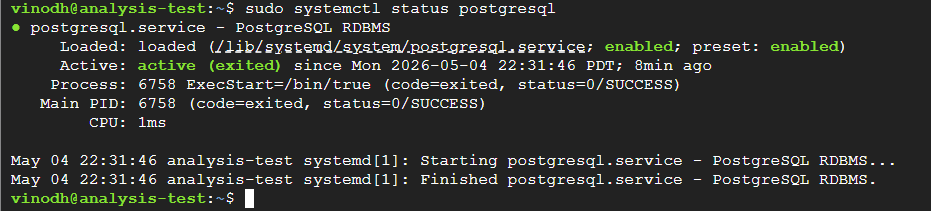

GCP Firewall Rule:

Name: allow-postgres

Type: Ingress

Targets: Apply to all

Filters: IP ranges: 0.0.0.0/0

Protocols/ports: tcp:5432

Action: Allow

Priority: 1000

Network: default

### 6.2 Connect from Colab

Install the `psycopg2` library and connect to your PostgreSQL database from this notebook. Replace the placeholder values with your actual Analysis VM external IP, username, and password.

In [ ]:
!pip install psycopg2-binary --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 69.0 MB/s eta 0:00:00


In [ ]:
import psycopg2
from google.colab import userdata

DB_HOST = "34.62.196.83"   # replace with your VM's external IP
DB_PORT = 5432
DB_NAME = "breadcrumbs"
DB_USER = "vinodh"           # replace

# note that your VM's external IP address is dynamic by default, and it changes
# every time you restart the analysis VM.
# So you must update this code cell's DB_HOST variable every time
# you restart your analysis VM. Or, if you prefer, explore how to create a
# static IP address for your VM.

# to avoid storing passwords as plaintext in code cells,
# colab provides a feature called "Secrets" to allow you to type a secret
# parameter value (such as a password) into your colab notebook's sidebar.
# do this by selecting the key icon found along the lefthand side of your notebook.
# create a secret called "db_password" and give it the value of your db user's password.
# once you do this, this code cell will be able to read the db_password
# with the following call to userdata.get('db_password')
DB_PASS = userdata.get('db_password')

conn = psycopg2.connect(
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASS
)
conn.autocommit = True
cur = conn.cursor()

print("Connected to PostgreSQL successfully.")
cur.execute("SELECT version();")
print(cur.fetchone()[0])

Connected to PostgreSQL successfully.
PostgreSQL 15.16 (Debian 15.16-0+deb12u1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit


### 6.3 Create the BreadCrumb Table

Run the cell below to create the `breadcrumb` table in your database. The schema reflects the fields that remain after transformation.

In [ ]:
create_table_sql = """
CREATE TABLE IF NOT EXISTS breadcrumb (
    trip_id     INTEGER       NOT NULL,
    vehicle_id  INTEGER       NOT NULL,
    timestamp   TIMESTAMP     NOT NULL,
    latitude    DOUBLE PRECISION NOT NULL,
    longitude   DOUBLE PRECISION NOT NULL,
    speed       DOUBLE PRECISION,
    meters      INTEGER
);
"""

cur.execute(create_table_sql)
print("breadcrumb table created (or already exists).")

breadcrumb table created (or already exists).


---
## 7. Store the BreadCrumb Data

Update `analysis.py` to insert each valid, transformed breadcrumb record into the `breadcrumb` table after transformation. You are free to use any of the load/store techniques that you practiced in the Data Storage lab assignment.

**Describe your approach for loading breadcrumb records into the DBMS:**

Briefly explain how your `analysis.py` program connects to PostgreSQL and inserts records. Does it insert one record at a time as each message arrives, or does it batch inserts? What are the trade-offs of your approach?

Our analysis.py connects to PostgreSQL using psycopg2 at the start of
each day's processing run. The connection is made with autocommit=True
so each insert is committed immediately.

We insert records one at a time as each valid, transformed breadcrumb
arrives from Pub/Sub. After validation and transformation pass, the
record is immediately inserted into the breadcrumb table using a
parameterized INSERT statement.

Trade-offs of this approach:

Advantages:
- Simple to implement and debug
- If the pipeline crashes mid-run, all records inserted so far are
  already committed and safe in the database
- No memory buildup from holding records in a buffer

Disadvantages:
- Slower than batch inserts because each record requires a separate
  round-trip to the database
- Higher overhead per record compared to batching 500-1000 records
  at once
- In a production system with millions of records, batch inserts
  using psycopg2's executemany() or COPY command would be significantly
  faster

For this project with ~500,000-700,000 records per day, single inserts
are acceptable since the pipeline runs overnight and throughput is not
the primary concern.

---
## 8. Pipeline Run Statistics

Record five successful days of full end-to-end automated pipeline runs in the table below. A successful day is one in which your pipeline automatically processes all of your vehicle group's breadcrumb records end-to-end, including gathering, transporting, validating, transforming and loading. The five days do not need to be consecutive.

| PIPELINE DATE | TRIMET DATE | BREADCRUMBS | VALIDATION ERRORS | STORED | VEHICLES | THROUGHPUT (msg/sec) |
|---|---|---|---|---|---|---|
| 2026-05-05 | 2023-01-06 | 716,640 | 15,775 | 700,865 | 162 | 405.8 |
| 2026-05-06 | 2023-01-07 | 525,988 | 13,201 | 512,787 | 123 | 456.9 |
| [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] |
| [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] |
| [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] | [YOUR INPUT HERE] |

**Column definitions:**
- **PIPELINE DATE** -- the calendar date on which your pipeline ran.
- **TRIMET DATE** -- the date represented in the `timestamp` field of the breadcrumbs processed that day.
- **BREADCRUMBS** -- total number of breadcrumb messages received by `analysis.py`.
- **VALIDATION ERRORS** -- number of breadcrumbs dropped due to validation failures.
- **STORED** -- number of rows successfully inserted into the breadcrumbs table in the database.
- **VEHICLES** -- number of unique `vehicle_id` values seen that day.
- **THROUGHPUT** -- breadcrumbs per second processed by `analysis.py`. this should include all time needed for pulling, validating, transforming and storing the breadcrumbs.

---
## 9. Exploratory Data Analysis

A data engineer typically uses exploratory analysis as a sanity test for a data pipeline. After each/any successful run of your pipeline, run the queries below to verify that the data looks reasonable. If something looks wrong, investigate before moving on.

### 9.1 Sanity-Check Queries

Run each of the provided queries and review the output.

In [ ]:
import pandas as pd

# Sanity check 1: How many breadcrumbs are in the database?
cur.execute("SELECT COUNT(*) AS total_breadcrumbs FROM breadcrumb;")
result = cur.fetchone()
print(f"Total breadcrumbs in database: {result[0]:,}")

Total breadcrumbs in database: 2,220,694


In [ ]:
# Sanity check 2: What date range is covered by the stored data?
cur.execute("""
    SELECT
        MIN(timestamp) AS earliest,
        MAX(timestamp) AS latest,
        COUNT(DISTINCT DATE(timestamp)) AS distinct_days
    FROM breadcrumb;
""")
row = cur.fetchone()
print(f"Earliest timestamp : {row[0]}")
print(f"Latest timestamp   : {row[1]}")
print(f"Distinct days      : {row[2]}")

Earliest timestamp : 2023-01-05 04:03:42
Latest timestamp   : 2023-01-07 00:00:00
Distinct days      : 3


In [ ]:
# Sanity check 3: Distribution of speed values -- are there any unrealistic speeds?
cur.execute("""
    SELECT
        ROUND(MIN(speed)::numeric, 2)  AS min_speed_mps,
        ROUND(MAX(speed)::numeric, 2)  AS max_speed_mps,
        ROUND(AVG(speed)::numeric, 2)  AS avg_speed_mps,
        COUNT(*) FILTER (WHERE speed > 40) AS records_above_40mps
    FROM breadcrumb
    WHERE speed IS NOT NULL;
""")
df_speed = pd.DataFrame(cur.fetchall(), columns=["min_speed_mps", "max_speed_mps", "avg_speed_mps", "records_above_40mps"])
display(df_speed)

,min_speed_mps,max_speed_mps,avg_speed_mps,records_above_40mps
0,0.00,71.80,8.65,3


### 9.2 Your Additional Queries

Implement three additional SQL queries to further validate or explore the data in the database. Document what each query is checking and interpret the results for one run of the queries (no need to show multiple days of results for these exploratory queries).

**Suggested ideas (choose any three, or invent your own):**
- Number of breadcrumbs per vehicle -- are any vehicles unusually over- or under-represented?
- Number of breadcrumbs per trip -- what is the range? Are there any suspiciously short trips?
- Average speed per trip -- which trips are slowest / fastest?
- Breadcrumbs per day -- is the count consistent across days, or are some days missing data?
- GPS bounding box -- do all coordinates fall within the Portland metropolitan area?

In [ ]:
# Your query 1
# Describe what this query checks:
# Number of breadcrumbs per vehicle - checks if any vehicles are
# unusually over or under-represented in the data

query1 = """
SELECT vehicle_id, COUNT(*) as breadcrumb_count
FROM breadcrumb
GROUP BY vehicle_id
ORDER BY breadcrumb_count DESC
LIMIT 10;
"""

cur.execute(query1)
df1 = pd.DataFrame(cur.fetchall(), columns=[col.name for col in cur.description])
display(df1)

,vehicle_id,breadcrumb_count
0,2939,26395
1,3042,25625
2,3028,24270
3,2919,22473
4,3721,21880
5,4036,21710
6,3210,21185
7,3018,21114
8,4046,21101
9,3055,20896


**Interpretation of Query 1:**

The query shows the top 10 vehicles by breadcrumb count. Vehicle 2939
has the most breadcrumbs with 26,395 records, while most vehicles have
between 20,000 and 26,000 breadcrumbs. The counts are relatively
consistent across vehicles, suggesting no vehicle is unusually
over-represented. Minor differences are expected since some buses run
longer routes or more trips than others.

In [ ]:
# Your query 2
# Describe what this query checks:
# Average speed per trip - identifies which trips are slowest and fastest

query2 = """
SELECT trip_id,
       ROUND(AVG(speed)::numeric, 2) as avg_speed_mps,
       COUNT(*) as breadcrumb_count
FROM breadcrumb
GROUP BY trip_id
ORDER BY avg_speed_mps DESC
LIMIT 10;
"""

cur.execute(query2)
df2 = pd.DataFrame(cur.fetchall(), columns=[col.name for col in cur.description])
display(df2)

,trip_id,avg_speed_mps,breadcrumb_count
0,242852012,26.48,249
1,232406444,22.37,334
2,232750940,21.59,294
3,232261509,21.26,239
4,233218110,20.73,264
5,232180562,20.58,271
6,232507285,20.58,332
7,233171848,20.18,188
8,233033474,19.72,270
9,232484707,19.60,880


**Interpretation of Query 2:**

The query shows the 10 fastest trips by average speed. The fastest trip
(242852012) averaged 26.48 m/s which is about 59 mph — unusually fast
for a city bus and likely represents a highway or freeway segment. Most
trips average between 19-22 m/s (43-49 mph). Trips with higher breadcrumb
counts tend to be longer routes. The variation in average speed reflects
different route types — some buses travel on highways while others are
mostly on city streets.

In [ ]:
# Your query 3
# Describe what this query checks:
# GPS bounding box - verifies all coordinates fall within
# the Portland metropolitan area

query3 = """
SELECT
    ROUND(MIN(latitude)::numeric, 4)  AS min_lat,
    ROUND(MAX(latitude)::numeric, 4)  AS max_lat,
    ROUND(MIN(longitude)::numeric, 4) AS min_lon,
    ROUND(MAX(longitude)::numeric, 4) AS max_lon,
    COUNT(*) FILTER (WHERE latitude < 45.0 OR latitude > 46.0
                     OR longitude < -123.5 OR longitude > -122.0)
                     AS outside_portland
FROM breadcrumb;
"""

cur.execute(query3)
df3 = pd.DataFrame(cur.fetchall(), columns=[col.name for col in cur.description])
display(df3)

,min_lat,max_lat,min_lon,max_lon,outside_portland
0,45.2851,45.6391,-123.1159,-122.3329,0


**Interpretation of Query 3:**

The query verifies that all GPS coordinates fall within the Portland
metropolitan area bounds. All breadcrumbs have:
- Latitude between 45.2851 and 45.6391 (within Portland metro range)
- Longitude between -123.1159 and -122.3329 (within Portland metro range)
- 0 records outside Portland bounds

This confirms our GPS validation is working correctly and all stored
records represent real TriMet bus locations within the Portland area.

### 9.3 Trip Visualization

Visualize a single bus trip on a map using Folium. Each breadcrumb for the trip is plotted as a small circle marker, color-coded by speed:
- **Green** -- fast (above 10 m/s)
- **Yellow** -- slow (3 to 10 m/s)
- **Red** -- very slow or stopped (below 3 m/s)

The cell below fetches all breadcrumbs for a single trip from your database and plots them. Replace `<TRIP_ID>` with a real trip_id from your data.

In [ ]:
# To Find a good trip_id to visualize by selecting the trips with the most
# breadcrumbs — more breadcrumbs means a longer route and better visualization

cur.execute("""
    SELECT trip_id, COUNT(*) as count
    FROM breadcrumb
    GROUP BY trip_id
    ORDER BY count DESC
    LIMIT 5;
""")
for row in cur.fetchall():
    print(row)

(232464658, 3621)
(232464984, 2808)
(232536473, 2754)
(232608264, 2748)
(232464823, 2685)


In [ ]:
!pip install folium --quiet
import folium

In [ ]:
TRIP_ID = "232464658"   # replace with a real trip_id from your data

cur.execute("""
    SELECT latitude, longitude, speed, timestamp
    FROM breadcrumb
    WHERE trip_id = %s
    ORDER BY timestamp;
""", (TRIP_ID,))

rows = cur.fetchall()
print(f"Loaded {len(rows)} breadcrumbs for trip {TRIP_ID}")

if len(rows) == 0:
    print("No data found for this trip. Check your TRIP_ID.")
else:
    # Center map on the median position of this trip
    center_lat = sum(r[0] for r in rows) / len(rows)
    center_lon = sum(r[1] for r in rows) / len(rows)

    trip_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=13,
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
        attr="Esri"
    )

    def speed_color(speed):
        """Return a color string based on speed in meters per second."""
        if speed is None:
            return "gray"
        if speed >= 10:
            return "green"
        if speed >= 3:
            return "orange"
        return "red"

    for lat, lon, speed, ts in rows:
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=speed_color(speed),
            fill=True,
            fill_opacity=0.8,
            popup=f"Speed: {speed} m/s | {ts}"
        ).add_to(trip_map)

    display(trip_map)

Loaded 3621 breadcrumbs for trip 232464658


**Describe what you observe in the trip map:**

We visualized trip 232464658 which contains 3,621 breadcrumb records
making it the longest trip in our dataset.

The map shows a bus route traveling east-west across Portland starting
from Beaverton on the west side, going through downtown Portland, and
continuing east toward Gresham. This appears to be a MAX light rail or
major bus line along the Highway 26/I-84 corridor.

The speed color pattern reveals:

- Green markers (fast, above 10 m/s) dominate most of the route
  indicating the bus travels at good speed along the main corridor.

- Orange markers (slow, 3-10 m/s) appear at several points especially
  around downtown Portland where traffic is heavier.

- Red markers (very slow or stopped, below 3 m/s) cluster at specific
  points in Beaverton, downtown Portland and near Gresham these are
  likely bus stops or traffic signals where the bus stops to pick up
  and drop off passengers.

The overall pattern shows a typical urban bus route with faster speeds
on open road segments and slower speeds at stops and intersections.

---
## 10. Reflections

Answer each question below in complete sentences. Aim for one to three paragraphs per question.

---

**Q1. Describe how your pipeline ensures that all published messages are processed by your subscribers.**

Explain the mechanism you implemented (or verified already worked) to handle out-of-order messages in GCP Pub/Sub. If you used the total-count sentinel approach, describe how it works. If you used a different technique, describe that instead. What edge cases remain unhandled?

We implemented the total-count sentinel approach to ensure all published
messages are processed. After publishing all breadcrumbs, publisher.py
includes the exact count of published messages in the sentinel payload
as a JSON field called total_count. When analysis.py and backup.py
receive the sentinel, they continue pulling messages from their
subscriptions until the number of breadcrumbs received equals
total_count. Only then do they close out the day's processing.

This approach is more reliable than our Part 1 method which used a
fixed 30-second drain window after the sentinel. With the drain window
approach, messages arriving more than 30 seconds late would be missed.
The total_count approach guarantees all messages are received regardless
of timing.

Edge cases that remain unhandled include duplicate messages — if Pub/Sub
delivers a message twice, our counter would reach total_count early and
stop pulling before all unique breadcrumbs are received. Additionally if
the publisher crashes mid-run the sentinel may never arrive leaving
subscribers waiting indefinitely.

---

**Q2. There are many ways to load data into a DBMS. Describe your approach for loading breadcrumb records into your database.**

Did you insert records one at a time as each Pub/Sub message arrived, or did you batch records and insert them all at once when the sentinel arrived? What are the trade-offs of your approach in terms of throughput, memory usage, and fault tolerance?

Our analysis.py inserts records one at a time as each valid transformed
breadcrumb arrives from Pub/Sub. After validation and transformation pass,
the record is immediately inserted into the breadcrumb table using a
parameterized INSERT statement with psycopg2 and autocommit enabled.

The main advantage of this approach is fault tolerance — if the pipeline
crashes mid-run all records inserted so far are already committed and safe
in the database. There is no risk of losing a large batch of records due
to a single failure. It is also simple to implement and debug.

The main disadvantage is lower throughput compared to batch inserts. Each
record requires a separate round-trip to the database which adds overhead.
Our observed throughput of around 400 breadcrumbs per second reflects this
overhead. In a production system with millions of records per day we would
use psycopg2 executemany or PostgreSQL COPY command to batch thousands of
records per insert and achieve significantly higher throughput.

---

**Q3. Describe the validation violations you observed in the BreadCrumb data. Which assertion produced the most violations? Were the violations what you expected, or did they surprise you?**

We observed 15,775 validation violations out of 716,640 breadcrumbs
— about 2.2% of records failed validation.

The most common violation was ACT_TIME out of range with 15,330 records
(97% of all violations). These records had ACT_TIME values greater than
86,400 seconds — meaning buses were still running past midnight. For
example ACT_TIME of 86,861 means 24 hours and 7 minutes past midnight.
This was surprising because we assumed all bus operations would complete
within a single calendar day.

The second most common violation was GPS_LATITUDE and GPS_LONGITUDE null
with 449 records each (3% of violations). These occur when the GPS
receiver loses satellite signal and cannot compute a position fix.

---

**Q4. Reflect on the data transformation steps. Which transformation do you think added the most value for downstream analysis, and why? What additional transformations might be useful for analysis or visualization of the data?**

The most valuable transformation was creating the timestamp field by
combining OPD_DATE and ACT_TIME into a single datetime object. The raw
data stores date and time as two separate fields in different formats
which makes time-based analysis very difficult. By combining them into
a proper timestamp we enabled standard SQL time queries sorting by time
and calculating time differences between consecutive breadcrumbs.

The speed calculation was also highly valuable because speed is not
directly measured by the GPS sensor — it must be derived from consecutive
position readings. Without this transformation downstream analysts would
have to recompute speed themselves every time they query the data.

Additional transformations that would be useful include computing the
distance between consecutive GPS coordinates to verify the METERS field,
adding a route_id field by joining with TriMet stop event data, and
adding a day_of_week field to enable analysis of bus patterns by weekday
versus weekend.

---

**Q5. The speed field you computed is based on consecutive breadcrumbs within the same trip. What factors could cause the computed speed to be inaccurate or misleading? How might you detect or correct for those factors?**

Several factors could cause the computed speed to be inaccurate. First
GPS coordinates have inherent measurement error — even with good satellite
coverage positions can be off by several meters. When two consecutive
readings have position errors in opposite directions the computed distance
and therefore speed will be inflated. This likely explains the maximum
speed of 71.80 m/s we observed which is physically impossible for a bus.

Second the breadcrumb sampling interval is approximately 5 seconds but
is not exactly 5 seconds. If a reading is delayed or arrives early the
time delta used in the speed calculation will be wrong. Third our speed
is calculated using the METERS odometer field rather than GPS coordinates
which is more reliable for measuring distance but still subject to
odometer errors.

To detect inaccurate speeds we could flag records where speed exceeds a
reasonable maximum such as 40 m/s which is about 90 mph. To correct for
GPS errors we could apply a smoothing filter such as a rolling average
over several consecutive readings to reduce the impact of individual
outliers.

In [ ]:
# Close the database connection when you are done with the notebook.
cur.close()
conn.close()
print("Database connection closed.")

Database connection closed.
